In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
delta_t = reader.fetch_data_from_h5("C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D");

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sethx\AppData\Local\Temp\ipykernel_21760\1863240305.py:18: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f"Turbulence saturation, r = {radial_index}/255, $\delta = -0.3$", fontsize=14);


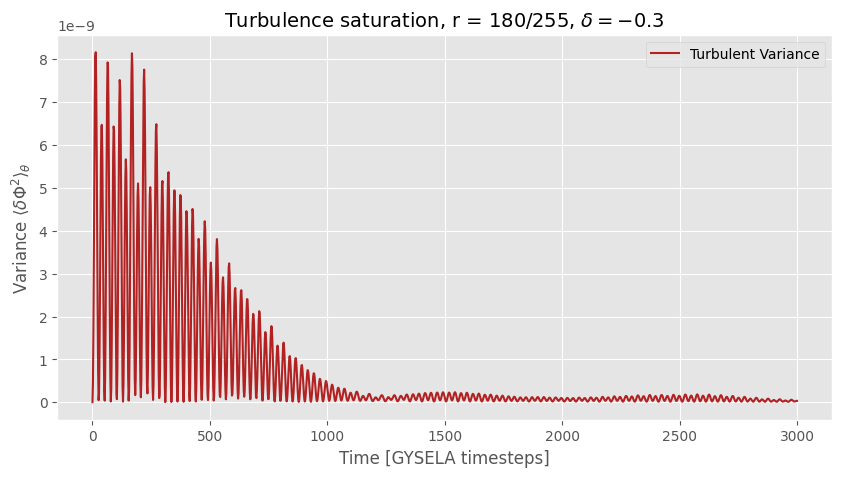

In [ ]:
def generate_turbulent_variance_time_series(phi2D_list):

	operation = lambda entry: (entry ** 2).mean(dim = "theta") - (entry.mean(dim = "theta")) ** 2;
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	variance_series = xr.concat(radial_strips, dim = "time");
	return variance_series;

def plot_turbulence_saturation(phi2D_list, radial_index, delta_t, dt_diag):

	variance_series = generate_turbulent_variance_time_series(phi2D_list);
	data_to_plot = variance_series.isel(r = radial_index).values;
	stride = utils.calculate_stride(delta_t, dt_diag);
	time_range = np.arange(len(variance_series)) * stride;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range, data_to_plot, color='firebrick', lw=1.5, label='Turbulent Variance');
	plt.title(f"Turbulence saturation, r = {radial_index}/255, $\delta = -0.3$", fontsize=14);
	plt.xlabel("Time [GYSELA timesteps]", fontsize=12);
	plt.ylabel(r"Variance $\langle \delta \Phi^2 \rangle_\theta$", fontsize=12);
	plt.legend();
	plt.show();

plot_turbulence_saturation(data_arrays, 180, delta_t, dt_diag = 50);